### Nipype SPM workflows - understand steps

target GLM :
(risky vs. safe,  just risky, just safe) x (intercept, pmod) 

| only second & pmod= pure numerosity (not value!)

In [1]:
from nilearn import plotting
%matplotlib inline
from os.path import join as opj
import json
from nipype.interfaces.base import Bunch
from nipype.interfaces.spm import Level1Design, EstimateModel, EstimateContrast, SPMCommand, Info, model
from nipype.interfaces.matlab import MatlabCommand
from nipype.interfaces.freesurfer import FSCommand
from nipype.algorithms.modelgen import SpecifySPMModel, SpecifyModel
from nipype.interfaces.utility import Function, IdentityInterface
from nipype.interfaces.io import SelectFiles, DataSink
from nipype import Workflow, Node
from bids.layout import BIDSLayout
from glob import glob
from scipy import io, stats
from itertools import chain
import pandas as pd
import numpy as np
#import pytest as pt # not even needed
import nibabel as nb
import nipype
import os.path as op
print(nipype.__file__)

import socket
from nipype.interfaces import spm

hostname = socket.gethostname()

if hostname == 'mr-02':
    MatlabCommand.set_default_paths('/home/ubuntu/matlab/spm12') # 
    bids_folder = '/mnt_01/ds-stressrisk' 
elif hostname == 'Econ117':
    MatlabCommand.set_default_paths('/Users/mrenke/matlab/spm12')
    MatlabCommand.set_default_matlab_cmd('/Applications/MATLAB_R2021b.app/bin/matlab')
    spm.SPMCommand.set_mlab_paths(matlab_cmd="/Applications/MATLAB_R2021b.app/bin/matlab") # error during spm.EstimateModel, solved: https://neurostars.org/t/nipype-spm-spmcommand-version-does-not-return-anything-on-mac/2871
    bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'

print(spm.SPMCommand().version)

/home/ubuntu/miniforge3/envs/nipype_spm/lib/python3.10/site-packages/nipype/__init__.py
12.7771


stty: 'standard input': Inappropriate ioctl for device


In [2]:
layout = BIDSLayout(bids_folder, derivatives=True)

# list of subject identifiers
subject_list = layout.get_subjects()

In [3]:
# TR of functional images
sub='01'
ses = 1
run = 1

with open(op.join(bids_folder, 'sub-01', 'ses-1','func', 'sub-01_ses-1_task-risk_run-1_bold.json'), # 'derivatives/fmriprep' , 
    "rt",
) as fp:
    task_info = json.load(fp)
TR = task_info["RepetitionTime"]
Nslices = len(task_info['SliceTiming']) # = 39
refSlice = 20 #Nslices / 2

### A priori: smoothing

In [ ]:
# unzip and move to spm_nipype folder
from nipype.algorithms.misc import Gunzip
import os
import shutil
import glob

ses_List = [1]
for sub in subject_list:
    for ses in ses_List:
        preproc_files = op.join(bids_folder,'derivatives/fmriprep',f'sub-{sub}', f'ses-{ses}', 'func',f'*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz') # has .gz at end.. might be a problem later?
        functional_runs = glob.glob(preproc_files)

        for functional_run in functional_runs:
        #if functional_run.endswith('.gz'):
            gunzip = Gunzip(in_file=functional_run)
            res = gunzip.run()
            print(res.outputs.out_file)
            out_file = res.outputs.out_file

            new_out_path = op.join(bids_folder,'derivatives/spm_nipype',f'sub-{sub}', f'ses-{ses}')
            os.makedirs(new_out_path, exist_ok=True)

            new_out_file = op.join(new_out_path, out_file.split('/')[-1])
            shutil.move(out_file, new_out_file) 
            print(new_out_file)
                    
#smooth.inputs.in_files = '/Volumes/mrenkeED/data/ds-stressrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-risk_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'
#'/Volumes/mrenkeED/data/ds-stressrisk/derivatives/fmriprep/sub-01/ses-1/sub-01_ses-1_task-risk_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii'#functional_runs[0]

In [ ]:
# smooth files and move to spm_nipype folder
sub='02'   
ses=1
from nipype.interfaces import spm

preproc_files = op.join(bids_folder,'derivatives/spm_nipype',f'sub-{sub}', f'ses-{ses}', f'*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii')
functional_runs = glob.glob(preproc_files)

for functional_run in functional_runs:
    print(functional_run)                      
    smooth = Node(interface=spm.Smooth(), name="smooth")
    smooth.inputs.in_files = functional_run
    #smooth.output_dir = new_out_path
    smooth.inputs.fwhm = [6, 6 ,6]
    res_smooth = smooth.run()
    print(res_smooth.outputs.smoothed_files)

    out_files = res_smooth.outputs.smoothed_files
    new_out_path = op.join(bids_folder,'derivatives/spm_nipype',f'sub-{sub}', f'ses-{ses}')

    #for file in out_files:
    file = res_smooth.outputs.smoothed_files
    shutil.move(file, op.join(new_out_path, file.split('/')[-1]))



In [7]:
from utils import smooth_image


for sub in subject_list:
    for ses in [1,2]:
        for run in range(1,7):
            smoothed_nifti_file = op.join(bids_folder, 'derivatives/spm_nipype', f'sub-{sub}', f'ses-{ses}', f'ssub-{sub}_ses-{ses}_task-risk_run-{run}_space-MNI152NLin2009cAsym_desc-preproc_bold.nii')
            if not op.exists(smoothed_nifti_file):
                print(f'missing: sub-{sub}_ses-{ses}_run-{run}')
                smooth_image(sub, ses, run, bids_folder=bids_folder)

missing: sub-02_ses-2_run-3
240312-08:37:16,770 nipype.workflow INFO:
	 [Node] Setting-up "smooth" in "/tmp/tmpskfqn856/smooth".
240312-08:37:16,773 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>
240312-08:37:51,820 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 35.045945s.


stty: 'standard input': Inappropriate ioctl for device


missing: sub-03_ses-1_run-4
240312-08:37:52,73 nipype.workflow INFO:
	 [Node] Setting-up "smooth" in "/tmp/tmpz6qqpwnf/smooth".
240312-08:37:52,77 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>
240312-08:38:28,768 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 36.689657s.
missing: sub-03_ses-2_run-3
240312-08:38:28,955 nipype.workflow INFO:
	 [Node] Setting-up "smooth" in "/tmp/tmpg4ct_l2t/smooth".
240312-08:38:28,958 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>


stty: 'standard input': Inappropriate ioctl for device


240312-08:39:05,26 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 36.066765s.
missing: sub-04_ses-1_run-6
240312-08:39:05,218 nipype.workflow INFO:
	 [Node] Setting-up "smooth" in "/tmp/tmpvciflvi8/smooth".
240312-08:39:05,221 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>


...

stty: 'standard input': Inappropriate ioctl for device


240312-09:36:45,421 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 37.01221s.
missing: sub-61_ses-2_run-4
240312-09:36:45,601 nipype.workflow INFO:
	 [Node] Setting-up "smooth" in "/tmp/tmpa30rfw3d/smooth".
240312-09:36:45,604 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>


stty: 'standard input': Inappropriate ioctl for device


240312-09:37:24,349 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 38.744438s.


stty: 'standard input': Inappropriate ioctl for device


In [12]:
functional_run = '/mnt_01/ds-stressrisk/derivatives/spm_nipype/sub-02/ses-2/sub-02_ses-2_task-risk_run-3_space-MNI152NLin2009cAsym_desc-preproc_bold.nii'

smooth = Node(interface=spm.Smooth(), name="smooth")
smooth.inputs.in_files = functional_run
#smooth.output_dir = new_out_path
smooth.inputs.fwhm = [6, 6 ,6]
res_smooth = smooth.run()
print(res_smooth.outputs.smoothed_files)

out_files = res_smooth.outputs.smoothed_files
new_out_path = op.join(bids_folder,'derivatives/spm_nipype',f'sub-{sub}', f'ses-{ses}')

#for file in out_files:
file = res_smooth.outputs.smoothed_files
shutil.move(file, op.join(new_out_path, file.split('/')[-1]))

240311-15:04:41,934 nipype.workflow INFO:
	 [Node] Setting-up "smooth" in "/tmp/tmpx9f2bnyz/smooth".
240311-15:04:41,937 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>
240311-15:05:17,977 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 36.038282s.
/tmp/tmpx9f2bnyz/smooth/ssub-02_ses-2_task-risk_run-3_space-MNI152NLin2009cAsym_desc-preproc_bold.nii


stty: 'standard input': Inappropriate ioctl for device


'/mnt_01/ds-stressrisk/derivatives/spm_nipype/sub-02/ses-1/ssub-02_ses-2_task-risk_run-3_space-MNI152NLin2009cAsym_desc-preproc_bold.nii'

In [ ]:
err_list = []
for sub in subject_list[2:]:
    for ses in [1,2]:
        preproc_files = op.join(bids_folder,'derivatives/spm_nipype',f'sub-{sub}', f'ses-{ses}', f'sub*_space-MNI152NLin2009cAsym_desc-preproc_bold.nii')
        functional_runs = glob(preproc_files)

        try:
            for functional_run in functional_runs[1:]:                       
                smooth = Node(interface=spm.Smooth(), name="smooth")
                smooth.inputs.in_files = functional_run
                #smooth.output_dir = new_out_path
                smooth.inputs.fwhm = [6, 6 ,6]
                res_smooth = smooth.run()
                print(res_smooth.outputs.smoothed_files)

                out_files = res_smooth.outputs.smoothed_files
                new_out_path = op.join(bids_folder,'derivatives/spm_nipype',f'sub-{sub}', f'ses-{ses}')

                #for file in out_files:
                file = res_smooth.outputs.smoothed_files
                shutil.move(file, op.join(new_out_path, file.split('/')[-1]))

                print(functional_run)
        except:
            err_list += [f'sub-{sub}_ses-{ses}']



In [104]:
smooth = Node(interface=spm.Smooth(), name="smooth")

smooth.inputs.in_files = new_out_file

#smooth.output_dir = new_out_path
smooth.inputs.fwhm = [6, 6 ,6]

# Create a workflow
wf = Workflow(name='my_workflow')

# Add the node to the workflow
wf.add_nodes([smooth])

# Specify the base directory for the workflow
wf.base_dir = new_out_path

# Run the workflow
wf.run()


240229-12:02:04,607 nipype.workflow INFO:
	 Workflow my_workflow settings: ['check', 'execution', 'logging', 'monitoring']
240229-12:02:04,633 nipype.workflow INFO:
	 Running serially.
240229-12:02:04,634 nipype.workflow INFO:
	 [Node] Setting-up "my_workflow.smooth" in "/Volumes/mrenkeED/data/ds-stressrisk/derivatives/spm_nipype/sub-02/ses-1/my_workflow/smooth".
240229-12:02:04,651 nipype.workflow INFO:
	 [Node] Executing "smooth" <nipype.interfaces.spm.preprocess.Smooth>


stty: stdin isn't a terminal


240229-12:05:06,334 nipype.workflow INFO:
	 [Node] Finished "smooth", elapsed time 169.880871s.


stty: stdin isn't a terminal


### prepare subject session info inputs 
* events incl. pmods
* motion-confounds & physio --> regressors

In [14]:
def get_subject_info(subject):
    from glob import glob
    import numpy as np
    import pandas as pd
    from scipy import io, stats
    from nipype.interfaces.base import Bunch
    import os.path as op
    bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
    ses=1
    sub = subject
    subject_info = []

    functional_runs = []
    
    for run in range(1, 7):
        # events + pmods
        df_events = pd.read_csv(op.join(bids_folder, f'sub-{sub}', f'ses-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-{run}_events.tsv'), sep='\t')
        df_events.set_index(['trial_nr', 'trial_type'], inplace=True) # only look at second option
        df_events = df_events.xs('stimulus 2',0,'trial_type')[['onset','prob2','n2']]

        df_risky_num2 = df_events[df_events['prob2'] == 0.55]
        df_safe_num2 = df_events[df_events['prob2'] == 1]

        pmod = [Bunch(name=['num2_risky'], param=[df_risky_num2['n2'].values.tolist()], poly=[1]),
            Bunch(name=['num2_safe'],param=[df_safe_num2['n2'].values.tolist()], poly=[1])]
        onsets = [df_risky_num2['onset'].values.tolist(), df_safe_num2['onset'].values.tolist()]
        durations = [(np.ones(len(df_risky_num2))* 0.6).tolist(), (np.ones(len(df_safe_num2))* 0.6).tolist()]

        # regressors (confounds + physio)
        confounds = pd.read_csv(op.join(bids_folder, 'derivatives/fmriprep',f'sub-{sub}', f'ses-{ses}', 'func', 
                        f'sub-{sub}_ses-{ses}_task-risk_run-{run}_desc-confounds_timeseries.tsv'), sep='\t')

        confound_names = ["trans_x","trans_y","trans_z","rot_x","rot_y","rot_z","a_comp_cor_00","a_comp_cor_02","a_comp_cor_03","a_comp_cor_04"]
        confounds = confounds.loc[:, confound_names]

        fn_physio = op.join(bids_folder, 'derivatives/physiotoolbox',f'sub-{sub}', f'ses-{ses}', 'func', 
                            f'sub-{sub}_ses-{ses}_task-task_run-{run}_desc-retroicor_output.mat') # task-taks (not risk) 
        physio = io.loadmat(fn_physio, simplify_cells=True)["physio"]["model"]
        physio = pd.DataFrame(
            data=physio["R"],
            columns=physio["R_column_names"],
        )

        regressors = pd.concat([confounds, physio], axis=1)
        regressor_names = regressors.columns.values.tolist()

        # put all together
        conditions = ['risky', 'safe']
        subject_info.insert(
            run - 1,
            Bunch(
                conditions=conditions,
                onsets=onsets,
                durations=durations,
                pmod=pmod,
                tmod=None,
                orth=['No']*len(conditions),
                regressors=regressors.values.T.tolist(),
                regressor_names=regressor_names,
            ),
        )

        #nifit_file = op.join(bids_folder,'derivatives/fmriprep',f'sub-{sub}', f'ses-{ses}', 'func',)
        nifti_file =  op.join(bids_folder,'derivatives/spm', f'sub-{sub}', f'ses-{ses}', f'fwhm-8_sub-{sub}_ses-{ses}_task-risk_run-{run}_space-MNI152NLin2009cAsym_desc-preproc_bold.nii')
        functional_run = glob(nifti_file)[0]
        functional_runs.append(functional_run)

    return subject_info, functional_runs

# try function
subject_info, functional_runs = get_subject_info(subject_list[0])
functional_runs

In [17]:
# try Node with selfmade function

getsubjectinfo = Node(
    Function(
        input_names=["subject"],
        output_names=["subject_info", "functional_runs"],
        function=get_subject_info,
    ),
    name="getsubjectinfo",
)

getsubjectinfo.inputs.subject = subject_list[0]
result = getsubjectinfo.run()
print(result.outputs.subject_info[1])
print(result.outputs.functional_runs)

In [111]:
# codnitions from Ella
events_file = pd.read_csv('/Users/mrenke/git/stress_risk/stress_risk/fmri_analysis/glm_nipype/sub-01_task-learn_run-1_events.tsv',
delimiter="\t")
events_file_sorted = events_file.sort_values(by=["onset"])
events_file_sorted["trial_nr"] = events_file_sorted["trial_nr"].ffill()
events_file_sorted["runType"] = events_file_sorted["runType"].ffill()
run_type = events_file_sorted["runType"][0]

conditions = []

for group in events_file_sorted.groupby("trial_type"):
    conditions.append(str(group[0].capitalize() + run_type.capitalize()))
conditions

['ChoiceTactile', 'FeedbackTactile']

### modelspecification ?!

In [115]:
modelspec = Node(
    SpecifySPMModel(
        concatenate_runs=False,
        input_units="secs",
        output_units="secs", # 'scans' ??
        time_repetition=TR,
        high_pass_filter_cutoff=128,
    ),
    name="modelspec",
)

modelspec.inputs.subject_info = result.outputs.subject_info
modelspec.inputs.functional_runs = result.outputs.functional_runs

res_modelspec = modelspec.run()
print(res_modelspec.outputs.session_info)

### Generates an SPM design matrix

In [119]:
# Level1Design - Generates an SPM design matrix
level1design = Node(
    Level1Design(
        bases={"hrf": {"derivs": [0, 0]}},
        timing_units="secs",
        interscan_interval=TR,
        model_serial_correlations="AR(1)",
        microtime_resolution=Nslices,
        microtime_onset=refSlice,
        flags={"mthresh": 0.8, "globalnorm": 'None'},
        #mask_image="/mnt/d/multlearn-sns/SPM/mask_ICV.nii", ??
        volterra_expansion_order=1,
    ),
    name="level1design",
)

level1design.inputs.session_info = res_modelspec.outputs.session_info
res_level1design = level1design.run()
print(res_level1design.outputs.spm_mat_file)

# stty: stdin isn't a terminal --> Try running your script outside of Jupyter, in a regular Python environment in your terminal, to see if the error persists.
# more informative error output if you run the script in a terminal

In [133]:
print(res_level1design.outputs.spm_mat_file)


/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmpp9g556np/level1design/SPM.mat


### EstimateModel 

In [122]:
# EstimateModel - estimate the parameters of the model
level1estimate = Node(
    EstimateModel(estimation_method={"Classical": 1},write_residuals=False), name="level1estimate"
)

level1estimate.inputs.spm_mat_file = res_level1design.outputs.spm_mat_file
res_level1est = level1estimate.run()
print(res_level1est.outputs)

### Contrast: define & estimate

In [143]:
conditions = ['risky', 'safe']

def get_contrasts(subject_info):
    from nipype.interfaces.spm import EstimateContrast
    import os

    condition_names = ['risky', 'safe', 'riskyxnum2_risky^1', 'safexnum2_safe^1' ]
    con01 = ('num2_risky', 'T', [condition_names[0]], [1.]) #['num2_risky', 'T', [condition_names[0]], [1.]]
    con02 = ('num2_safe', 'T', [condition_names[1]], [1.])#['num2_safe', 'T', [condition_names[1]], [1.]]
    con03 = ('num2_risky-safe', 'T', condition_names[:2], [1/2., -1/2.]) #['num2_risky-safe', 'T', condition_names[:], [1/2., 1/2.]]
    con04 = ('num2_risky_pmod', 'T', [condition_names[2]], [1.])
    con05 = ('num2_safe_pmod', 'T', [condition_names[3]], [1.])
    con06 = ('num2_both_pmod', 'T', ['riskyxnum2_risky^1', 'safexnum2_safe^1'], [1/2., 1/2.])

    con_list = [con01, con02, con03, con04, con05,con06]

    return con_list

getcontrasts = Node(Function(
        input_names=["subject_info"],
        output_names=["contrasts"],
        function=get_contrasts),
        name="getcontrasts")

getcontrasts.inputs.subject_info = result.outputs.subject_info
result_con = getcontrasts.run()
print(result_con.outputs.contrasts)

240304-13:59:31,347 nipype.workflow INFO:
	 [Node] Setting-up "getcontrasts" in "/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmprh282bod/getcontrasts".
240304-13:59:31,440 nipype.workflow INFO:
	 [Node] Executing "getcontrasts" <nipype.interfaces.utility.wrappers.Function>
240304-13:59:31,441 nipype.workflow INFO:
	 [Node] Finished "getcontrasts", elapsed time 0.000375s.
[('num2_risky', 'T', ['risky'], [1.0]), ('num2_safe', 'T', ['safe'], [1.0]), ('num2_risky-safe', 'T', ['risky', 'safe'], [0.5, -0.5]), ('num2_risky_pmod', 'T', ['riskyxnum2_risky^1'], [1.0]), ('num2_safe_pmod', 'T', ['safexnum2_safe^1'], [1.0]), ('num2_both_pmod', 'T', ['riskyxnum2_risky^1', 'safexnum2_safe^1'], [0.5, 0.5])]


In [144]:
# EstimateContrast - estimates contrasts
level1conest = Node(EstimateContrast(), name="level1conest")
level1conest.inputs.contrasts =  result_con.outputs.contrasts
level1conest.inputs.spm_mat_file = res_level1est.outputs.spm_mat_file
level1conest.inputs.beta_images = res_level1est.outputs.beta_images
level1conest.inputs.residual_image = res_level1est.outputs.residual_image
res_level1con = level1conest.run()
print(res_level1con.outputs)

240304-13:59:32,477 nipype.workflow INFO:
	 [Node] Setting-up "level1conest" in "/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest".
240304-13:59:32,532 nipype.workflow INFO:
	 [Node] Executing "level1conest" <nipype.interfaces.spm.model.EstimateContrast>


stty: stdin isn't a terminal
stty: stdin isn't a terminal


240304-14:00:05,910 nipype.workflow INFO:
	 [Node] Finished "level1conest", elapsed time 22.079874s.

con_images = ['/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/con_0001.nii', '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/con_0002.nii', '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/con_0003.nii', '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/con_0004.nii', '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/con_0005.nii', '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/con_0006.nii']
ess_images = <undefined>
spmF_images = <undefined>
spmT_images = ['/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0001.nii', '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0002.nii', '/private/var/folders/3k/8g0xv78

In [145]:
res_level1con.outputs.spmT_images

['/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0001.nii',
 '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0002.nii',
 '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0003.nii',
 '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0004.nii',
 '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0005.nii',
 '/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmppkejcp5u/level1conest/spmT_0006.nii']

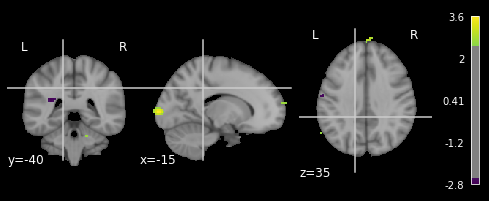

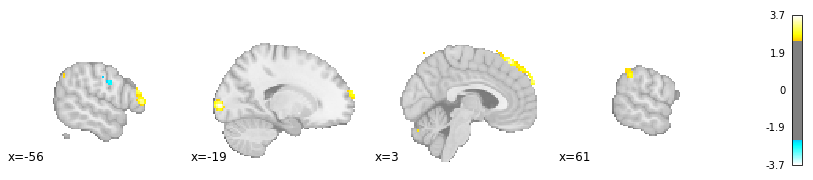

In [149]:
## look at results
import nibabel as nib
import nilearn.plotting as nipl
import matplotlib as mpl

spm_file = res_level1con.outputs.spmT_images[6-1]
spm = nib.load(spm_file)

anat_file = '/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz'
anat = nib.load(anat_file)

coords = [-15, -40, 35]
display = nipl.plot_anat(anat_img = anat, cut_coords = (coords[0], coords[1], coords[2]))
display.add_overlay(spm, threshold = 2.5, colorbar=True, cmap = mpl.colormaps['viridis'])

nipl.plot_stat_map(spm,threshold = 2.5,  draw_cross=False,  display_mode='x', cut_coords =4 ) #title=f'{model}-{version} {contrast}',


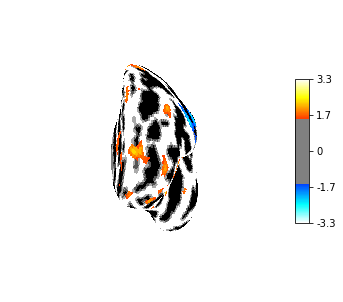

In [155]:
# plot on surface: left
import matplotlib.pyplot as plt
from nilearn import datasets, surface

fsaverage = datasets.fetch_surf_fsaverage()
curv_left = surface.load_surf_data(fsaverage.curv_left)
curv_left_sign = np.sign(curv_left)

texture = surface.vol_to_surf(spm, fsaverage.pial_left)

nipl.plot_surf_stat_map(surf_mesh= fsaverage.infl_left,stat_map= texture, 
    view='anterior',#'lateral',#' 'posterior',#
    hemi='left',
    #title=f'{model_n}, {con}', colorbar=True,
    threshold=1.5, bg_map=curv_left_sign) # bg_map: Background image to be plotted on the mesh underneath the stat_map in greyscale
plt.show()

### 2nd level SPM ?!

# SnpmOneSampleTTestInputSpec(BaseInterfaceInputSpec):
look at script :
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nipype/interfaces/spm

In [ ]:
import os
subject_list = range(1,64)
subject_list = [f'{sub:02d}' for sub in subject_list if sub not in [8, 13, 16, 31, 32, 44]]
for contrast in range(1,26):
    SnPM_2nd = Node(SnpmOneSampleTTest(), name='SnPM')
    sub_contrasts = list()
    for sub in subject_list:
        path_1stlevel = f'/mnt/d/multlearn-sns/SPM/nipype/model1/1stLevel/sub-{sub}/con_{contrast:04d}.nii'
        sub_contrasts.append(path_1stlevel)
    SnPM_2nd.inputs.contrasts = sub_contrasts
    destination = '/mnt/d/multlearn-sns/SPM/nipype/model1/2ndLevel/SnPM_SecondLevel_con' + str(contrast)
    if not os.path.exists(destination):
        os.makedirs(destination)
    SnPM_2nd.inputs.destination = destination
    SnPM_2nd.inputs.n_perms = 5000
    SnPM_2nd.inputs.var_smoothing = [0, 0, 0]
    SnPM_2nd.inputs.memory_usage = False
    SnPM_2nd.inputs.cluster_inference_later = -1
    SnPM_2nd.inputs.masking_none = 1
    SnPM_2nd.inputs.implicit_mask = 1
    SnPM_2nd.inputs.global_calc_omit = 1
    SnPM_2nd.inputs.no_grand_mean_scaling = 1
    SnPM_2nd.inputs.global_normalization = 1

    SnPM_2nd.run()

In [204]:
# SpecifyModel - Generates SPM-specific Model
modelspec = Node(
    SpecifySPMModel(
        concatenate_runs=False,
        input_units="secs",
        output_units="secs",
        time_repetition=TR,
        high_pass_filter_cutoff=128,
    ),
    name="modelspec",
)

# Level1Design - Generates an SPM design matrix
level1design = Node(
    Level1Design(
        bases={"hrf": {"derivs": [0, 0]}},
        timing_units="secs",
        interscan_interval=TR,
        model_serial_correlations="AR(1)",
    ),
    name="level1design",
)

# EstimateModel - estimate the parameters of the model
level1estimate = Node(
    EstimateModel(estimation_method={"Classical": 1}), name="level1estimate"
)

# EstimateContrast - estimates contrasts
level1conest = Node(EstimateContrast(), name="level1conest")

stty: 'standard input': Inappropriate ioctl for device


### Worflow: putting nodes together

In [57]:
# Create a Nipype workflow
first_level_wf = Workflow(name='first_level_wf')

# Connect the nodes
first_level_wf.connect([
    (getsubjectinfo, getcontrasts, [('subject_info', 'subject_info')]),
    (getsubjectinfo, modelspec, [('subject_info', 'subject_info')]),
    (getsubjectinfo, modelspec, [('functional_runs', 'functional_runs')]),
    (modelspec, level1design, [('session_info', 'session_info')]),
    (level1design, level1estimate, [('spm_mat_file', 'spm_mat_file')]),  # Connect level1design to level1estimate
    (getcontrasts, level1conest, [('contrasts', 'contrasts')]),  # Connect the contrasts to EstimateContrast
    (level1design, level1conest, [('spm_mat_file', 'spm_mat_file')])
])

getsubjectinfo.inputs.subject = '01'
first_level_wf.config['logging'] = {'workflow_level' : 'DEBUG',
                        'filemanip_level' : 'DEBUG',
                        'interface_level' : 'DEBUG',
                        'log_to_file' : 'True',
                        'log_directory' : '/output/log_folder'}


In [58]:
first_level_wf.run()

240229-10:48:13,528 nipype.workflow INFO:
	 Workflow first_level_wf settings: ['check', 'execution', 'logging', 'monitoring']
240229-10:48:13,620 nipype.workflow INFO:
	 Running serially.
240229-10:48:13,620 nipype.workflow INFO:
	 [Node] Setting-up "first_level_wf.getsubjectinfo" in "/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmpr2tric0f/getsubjectinfo".
240229-10:48:13,621 nipype.workflow INFO:
	 [Node] Outdated cache found for "first_level_wf.getsubjectinfo".
240229-10:48:13,639 nipype.workflow INFO:
	 [Node] Executing "getsubjectinfo" <nipype.interfaces.utility.wrappers.Function>
240229-10:48:14,231 nipype.workflow INFO:
	 [Node] Finished "getsubjectinfo", elapsed time 0.590064s.
240229-10:48:14,309 nipype.workflow INFO:
	 [Node] Setting-up "first_level_wf.getcontrasts" in "/private/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/tmpi6yphp2i/getcontrasts".
240229-10:48:14,362 nipype.workflow INFO:
	 [Node] Cached "first_level_wf.getcontrasts" - collecting precomputed 

In [ ]:
conditions = ['risky', 'safe']

def get_contrasts(subject_info):
    from nipype.interfaces.spm import EstimateContrast
    import os

    ses=1
    condition_names = [f'risky_num2_ses{ses}', f'safe_num2_ses{ses}']
    pmod_names = ['num2_risky', 'num2_safe']
    pmod_names = [f'{condition_names[0]}x{pmod_names[0]}^1',f'{condition_names[1]}x{pmod_names[1]}^1'] # 'riskyxnum2_risky^1'

    con01 = ('num2_risk', 'T', [condition_names[0]], [1/2.]) #['num2_risky', 'T', [condition_names[0]], [1.]]
    con02 = ('num2_safe', 'T', [condition_names[1]], [1/2.])#['num2_safe', 'T', [condition_names[1]], [1.]]
    con03 = ('num2_risky-safe', 'T', condition_names[:2], [1/4., -1/4.]) #['num2_risky-safe', 'T', condition_names[:], [1/2., 1/2.]]
    con04 = ('num2_risky_pmod', 'T', [condition_names[2]], [1.])
    con05 = ('num2_safe_pmod', 'T', [condition_names[3]], [1.])
    con06 = ('num2_both_pmod', 'T', ['riskyxnum2_risky^1', 'safexnum2_safe^1'], [1/2., 1/2.])
    
    ses=2
    condition_names = [f'risky_num2_ses{ses}', f'safe_num2_ses{ses}']
    pmod_names = ['num2_risky', 'num2_safe']
    pmod_names = [f'{condition_names[0]}x{pmod_names[0]}^1',f'{condition_names[1]}x{pmod_names[1]}^1'] # 'riskyxnum2_risky^1'
    con07 = ('num2_risky', 'T', [condition_names[0]], [1.]) #['num2_risky', 'T', [condition_names[0]], [1.]]
    con08 = ('num2_safe', 'T', [condition_names[1]], [1.])#['num2_safe', 'T', [condition_names[1]], [1.]]
    con03 = ('num2_risky-safe', 'T', condition_names[:2], [1/2., -1/2.]) #['num2_risky-safe', 'T', condition_names[:], [1/2., 1/2.]]
    con04 = ('num2_risky_pmod', 'T', [condition_names[2]], [1.])
    con05 = ('num2_safe_pmod', 'T', [condition_names[3]], [1.])
    con06 = ('num2_both_pmod', 'T', ['riskyxnum2_risky^1', 'safexnum2_safe^1'], [1/2., 1/2.])

    con_list = [con01, con02, con03, con04, con05,con06]

    return con_list

getcontrasts = Node(Function(
        input_names=["subject_info"],
        output_names=["contrasts"],
        function=get_contrasts),
        name="getcontrasts")

getcontrasts.inputs.subject_info = result.outputs.subject_info
result_con = getcontrasts.run()
print(result_con.outputs.contrasts)